# Generic batch growth: a forward-simulation homework example

This is an idealized, organism-independent capability demonstration, not a calibrated biological model.
Run the seven steps in order with **Shift+Enter**, using the same Python 3.11 environment as the other examples.
No Assimulo, estimation configuration, experiment-design configuration, or runner script is needed.

**Inputs:** `inputs/case.json` (operation and solver), `inputs/mechanism.json` (pathway, uptake cap, initial amounts), and `inputs/thermo.json` (phase properties).
**Outputs:** `outputs/trajectories.csv`, `outputs/trajectories.png`, and `outputs/summary.json`.
The notebook uses `build_bioreactor` and `assembly.solve()` directly. The default execution checks and plots results without writing files; Step 7 explains how to regenerate the supplied outputs.

### The homework model

A 1 L batch initially contains 10 mmol of hypothetical nutrient and 0.1 g dry biomass.
The single pathway maximizes growth subject to a constant specific uptake cap:

\[
\max_{v\geq0}v,\qquad a v\leq q_{\max},\qquad
\frac{dn}{dt}=-a v B,\qquad\frac{dB}{dt}=vB.
\]

Here time is in hours, nutrient amount $n$ is in mol, biomass $B$ is in kgDW,
$a=10$ mol/kgDW, $q_{\max}=2$ mol/(kgDW h), and pathway activity $v$ is in h$^{-1}$.
Before nutrient depletion, $v=\mu=q_{\max}/a=0.2$ h$^{-1}$ and

\[
 B(t)=B_0e^{\mu t},\qquad n(t)=n_0-a[B(t)-B_0].
\]

The effective nutrient molecular weight is 100 g/mol, giving an idealized yield of
1 gDW per g nutrient. Consequently **liquid mass + dry biomass** is conserved.
Liquid volume is calculated from the current liquid inventory at the declared constant density;
it is not artificially held at its initial value. Biomass volume is neglected.

These assumptions omit maintenance, death, respiration, gas transfer, product formation, and energy limitation.
The property data are illustrative placeholders for this isothermal dilute model, not an experimentally sourced thermodynamic database.
Mass closure here does not establish elemental or energetic closure.
The supplied six-hour run remains well before depletion (approximately 11.99 h).

## Step 1 — Imports and input locations

In [1]:
# STEP 1: Imports and input locations
# Run this cell first with Shift+Enter in the demonstrator's Python environment.
# If this notebook is outside the checkout, set repo_root explicitly. To use a
# copied example, change example_dir below. No runner scripts are imported.
from pathlib import Path
import csv
import hashlib
import json
import platform
import sys
import numpy as np
import scipy
import matplotlib.pyplot as plt

repo_root = next((path for path in (Path.cwd(), *Path.cwd().parents)
                  if (path / "PharmaPy").is_dir()), None)
if repo_root is None:
    raise ValueError("Set repo_root to your PharmaPy checkout before running this cell")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from PharmaPy.Bioreactors import build_bioreactor

example_dir = repo_root / "examples/bioreactors/generic_batch"
input_dir = example_dir / "inputs"
WRITE_ARTIFACTS = False
EXPORT_DIR = example_dir / "outputs"

## Step 2 — Load and edit the three inputs

In [2]:
# STEP 2: Load and edit model and operation settings
# Run to load the three JSON files. Edit them or uncomment the examples below,
# then rerun this cell and every following step. Amounts are mol and kgDW;
# reporting/runtime are hours, while the native solver uses seconds.
# Keep the one-nutrient/one-pathway structure and yield for the analytic check.
# Keep all liquid densities equal to carrier_density_kg_l * 1000 (kg/m3).
case = json.loads((input_dir / "case.json").read_text())
config = json.loads((input_dir / "mechanism.json").read_text())
thermo_path = input_dir / "thermo.json"

# config["state"]["biomass_kg"] = 0.0002
# config["model"]["parameters"]["nutrient_uptake_max"] = 1.0
# case["operation"]["runtime"]["value"] = 4.0
# To change volume, also change initial_mass_kg and state.liquid_volume_m3.

## Step 3 — Construct and run the native reactor

In [3]:
# STEP 3: Construct and run the forward simulation
# Run this cell after each input edit. A fresh assembly avoids carrying state
# from a previous solve. assembly.solve() calls the native reactor.solve_unit;
# no differential equations or optimizer are reimplemented in this notebook.
assembly = build_bioreactor(case, config, thermo_path)
unit = assembly.unit
histories = assembly.solve(verbose=False)
assert len(histories) == 1, "This homework notebook assumes an event-free batch"
result = histories[0]
print("Native reactor:", type(unit).__name__)
print("Backend:", type(unit.integrator).__name__)
print("Recorded times:", len(result.time))

Native reactor: BatchReactor
Backend: SciPyBackend
Recorded times: 61


## Step 4 — Extract inventories and concentrations

In [4]:
# STEP 4: Convert native results into a table with explicit units
# Run to inspect the forward results. Native species mass is kg and time is s.
# Concentrations use each recorded liquid volume, not the initial volume.
# If you change species or the property model, adapt these output mappings.
nutrient_index = list(assembly.phase.name_species).index("nutrient")
water_index = list(assembly.phase.name_species).index("water")
molecular_weight = float(assembly.phase.mw[nutrient_index])
time_h = np.asarray(result.time, dtype=float) / 3600.0
mass_kg = np.asarray(result.mass_j_liquid0, dtype=float)
biomass_kg = np.asarray(result.biomass_kg_liquid0, dtype=float).reshape(-1)
nutrient_mol = mass_kg[:, nutrient_index] * 1000.0 / molecular_weight
liquid_mass_kg = mass_kg.sum(axis=1)
volume_l = liquid_mass_kg / case["operation"]["carrier_density_kg_l"]
rows = [dict(time_h=float(t), nutrient_mmol=float(n * 1000.0),
             biomass_gdw=float(b * 1000.0), liquid_volume_l=float(volume),
             nutrient_mmol_l=float(n * 1000.0 / volume),
             biomass_gdw_l=float(b * 1000.0 / volume),
             liquid_plus_biomass_kg=float(mass + b))
        for t, n, b, volume, mass in zip(time_h, nutrient_mol, biomass_kg,
                                        volume_l, liquid_mass_kg)]
print("Initial row:", rows[0])
print("Final row:", rows[-1])

Initial row: {'time_h': 0.0, 'nutrient_mmol': 10.0, 'biomass_gdw': 0.1, 'liquid_volume_l': 1.0, 'nutrient_mmol_l': 10.0, 'biomass_gdw_l': 0.1, 'liquid_plus_biomass_kg': 1.0001}
Final row: {'time_h': 6.0, 'nutrient_mmol': 7.679882826563587, 'biomass_gdw': 0.3320117173436417, 'liquid_volume_l': 0.9997679882826563, 'nutrient_mmol_l': 7.681665062866881, 'biomass_gdw_l': 0.3320887658285121, 'liquid_plus_biomass_kg': 1.0001}


## Step 5 — Check the analytical solution and mass accounting

In [5]:
# STEP 5: Independently check the numerical trajectory
# Run to compare every output time with the closed-form solution and conserved
# quantities. The analytic formula assumes constant uptake before depletion.
# If a modified run extends past depletion, shorten it for this check or derive
# the piecewise solution; do not relax tolerances to hide a modeling change.
model = config["model"]
assert model["state_ids"] == ["nutrient"] and model["pathway_ids"] == ["assimilation"]
assert model["growth_coefficients"] == [1.0] and config["flux_time_unit"] == "1/h"
assert config["transport"] is None and not config["recipes"][case["recipe"]["name"]]
assert model["uptake_constraints"][0]["type"] == "constant"
a = -float(model["exchange_matrix"][0][0])
q_max = float(model["parameters"]["nutrient_uptake_max"])
assert a > 0.0 and q_max > 0.0
np.testing.assert_allclose(a * molecular_weight / 1000.0, 1.0, rtol=0, atol=1e-12)
properties = json.loads(thermo_path.read_text())
for species in properties.values():
    np.testing.assert_allclose(species["rho_liq"],
                               case["operation"]["carrier_density_kg_l"] * 1000.0)
mu = q_max / a
b0 = float(config["state"]["biomass_kg"])
n0 = float(config["state"]["species_mol"]["nutrient"])
biomass_exact = b0 * np.exp(mu * time_h)
nutrient_exact = n0 - a * (biomass_exact - b0)
if np.any(nutrient_exact <= 0.0):
    raise ValueError("Analytic check assumes available nutrient: shorten the run or derive a depletion solution")
assert np.isfinite(mass_kg).all() and np.isfinite(biomass_kg).all()
assert mass_kg.min() >= -1e-12 and biomass_kg.min() >= 0.0
np.testing.assert_allclose(biomass_kg, biomass_exact, rtol=1e-6, atol=1e-10)
np.testing.assert_allclose(nutrient_mol, nutrient_exact, rtol=1e-6, atol=1e-9)
total_mass = liquid_mass_kg + biomass_kg
initial_total = case["operation"]["initial_mass_kg"] + b0
np.testing.assert_allclose(total_mass, initial_total, rtol=0, atol=1e-10)
np.testing.assert_allclose(nutrient_mol + a * biomass_kg, n0 + a * b0,
                           rtol=0, atol=1e-9)
np.testing.assert_allclose(mass_kg[:, water_index], mass_kg[0, water_index],
                           rtol=0, atol=1e-10)
summary = {
    "status": "PASS", "native_unit": type(unit).__name__,
    "backend": type(unit.integrator).__name__, "recorded_rows": len(rows),
    "growth_rate_per_h": mu, "depletion_time_h": float(np.log1p(n0 / (a * b0)) / mu),
    "final": rows[-1],
    "maximum_biomass_relative_error": float(np.max(abs(biomass_kg / biomass_exact - 1.0))),
    "maximum_nutrient_absolute_error_mol": float(np.max(abs(nutrient_mol - nutrient_exact))),
    "maximum_total_mass_error_kg": float(np.max(abs(total_mass - initial_total))),
    "checks": {"analytical_solution": True, "nonnegative_inventories": True,
               "total_mass_conservation": True, "nutrient_biomass_balance": True,
               "constant_water_inventory": True},
    "acceptance": {"analytical_rtol": 1e-6, "biomass_atol_kgdw": 1e-10,
                   "nutrient_atol_mol": 1e-9, "total_mass_atol_kg": 1e-10},
    "effective_inputs": {"case": case, "mechanism": config},
    "thermo_sha256": hashlib.sha256(thermo_path.read_bytes()).hexdigest(),
    "environment": {"python": platform.python_version(), "numpy": np.__version__,
                    "scipy": scipy.__version__},
    "evidence_limit": "Analytic verification of an idealized mass-balanced model; not experimental validation."
}
print(json.dumps({key: summary[key] for key in ("status", "growth_rate_per_h", "final",
                 "maximum_biomass_relative_error", "maximum_total_mass_error_kg")}, indent=2))

{
  "status": "PASS",
  "growth_rate_per_h": 0.2,
  "final": {
    "time_h": 6.0,
    "nutrient_mmol": 7.679882826563587,
    "biomass_gdw": 0.3320117173436417,
    "liquid_volume_l": 0.9997679882826563,
    "nutrient_mmol_l": 7.681665062866881,
    "biomass_gdw_l": 0.3320887658285121,
    "liquid_plus_biomass_kg": 1.0001
  },
  "maximum_biomass_relative_error": 7.550934921773944e-08,
  "maximum_total_mass_error_kg": 0.0
}


## Step 6 — Plot the simulation and the independent solution

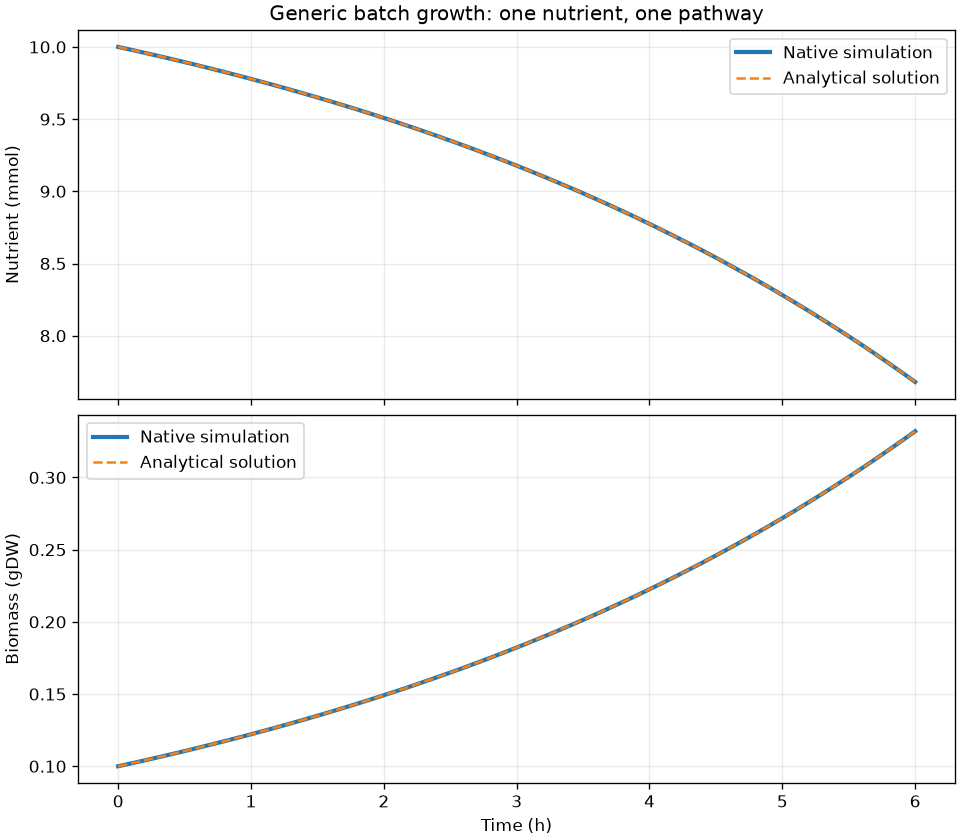

In [6]:
# STEP 6: Compare the numerical and analytical trajectories visually
# Run to display the figure. Solid curves are native simulation results;
# dashed curves are the independent formulas from Step 5. Overlap is expected.
# The table also provides concentration trajectories if you prefer those axes.
figure, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
axes[0].plot(time_h, nutrient_mol * 1000.0, label="Native simulation", linewidth=2.5)
axes[0].plot(time_h, nutrient_exact * 1000.0, "--", label="Analytical solution")
axes[0].set(ylabel="Nutrient (mmol)", title="Generic batch growth: one nutrient, one pathway")
axes[1].plot(time_h, biomass_kg * 1000.0, label="Native simulation", linewidth=2.5)
axes[1].plot(time_h, biomass_exact * 1000.0, "--", label="Analytical solution")
axes[1].set(xlabel="Time (h)", ylabel="Biomass (gDW)")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
figure

## Step 7 — Optionally save this run

In [7]:
# STEP 7: Export results only when requested
# Set WRITE_ARTIFACTS=True in Step 1 and rerun the notebook to regenerate outputs.
# Set EXPORT_DIR to a different folder to retain the supplied demonstration.
# The summary records effective input dictionaries, properties checksum,
# package versions, numerical checks, and units alongside the trajectory CSV.
if WRITE_ARTIFACTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    with (EXPORT_DIR / "trajectories.csv").open("w", newline="") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    (EXPORT_DIR / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")
    figure.savefig(EXPORT_DIR / "trajectories.png", dpi=160)
    print("Saved outputs to:", EXPORT_DIR)
else:
    print("No files written. Set WRITE_ARTIFACTS=True to export this run.")

No files written. Set WRITE_ARTIFACTS=True to export this run.


## Suggested homework variations

1. Double initial biomass. Predict the change in initial nutrient-consumption rate, then rerun.
2. Halve the uptake cap. Predict the growth rate and six-hour biomass before running.
3. Double initial nutrient while keeping the uptake cap fixed. Explain why growth is unchanged before depletion in this constant-uptake model.
4. Plot concentration instead of amount and explain the role of the small liquid-volume change.

Change inputs, not library code. Keep the original yield and property assumptions for the provided mass check.
For a Monod law, multiple pathways, feeds, or depletion, update the verification equations as well as the input configuration.